# Niet-lineair kredietverzuimrisico modelleren met regressiesplines

## Samenvatting

Een risicoteam van een retailbank wil weten *waar* het verzuimrisico niet-lineair wordt voordat het zich vastlegt op een productiescorekaart. In plaats van elk kenmerk met de hand vooraf in klassen te verdelen, fit het team een **gegeneraliseerd additief model** met `PROC GAM`: elk kenmerk van de kredietnemer gaat als een kubische smoothing-spline mee, zodat drempel- en U-vormige verbanden rechtstreeks uit de data op de logit-schaal worden geschat. Op een bewust ongunstige synthetische portefeuille van 100 leningen (39% in verzuim) verlaagt het additieve splinemodel de deviantie van 133,75 (alleen intercept) naar 61,69 — een daling van 72,06 — voor een model-AIC van 81,69. De gefitte schuld-inkomensmooth draagt de grootste coëfficiënt (4,34), en het in klassen verdelen van de ruwe uitkomst bevestigt de ingebouwde structuur: het verzuimrisico is sterk **U-vormig naar leeftijd** (66,7% bij de jongste kredietnemers, 4,8% op middelbare leeftijd, 86,4% bij de oudste) en loopt op met de hefboomwerking.

## Databronnen

| Dataset | Rijen | Rol | Kernvariabelen | Beschrijving |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Modelinvoer | `default` (0/1 doel), `age` (leeftijd), `dti` (schuld-inkomen), `utilization` (benutting doorlopend krediet) | Synthetische retail-kredietaanvragen. De ware log-odds van verzuim wordt opgebouwd met bewuste niet-lineariteiten — een U-vormig leeftijdseffect en drempelknikken in schuld-inkomen en benutting — en vervolgens Bernoulli-gesampled. Inline gegenereerd met `call streaminit(20260531)` en `rand()`; geen externe bestanden. |

Deze omgeving draait zonder licentie, dus de uitvoer is beperkt tot 100 waarnemingen. Het scenario is op die limiet afgestemd: het signaal is sterk genoeg gemaakt dat een additief splinemodel met drie termen de vormen uit 100 leningen kan terugvinden.

# Waarom splines voor kredietrisico

Traditionele scorekaarten leunen op logistische regressie met handmatig in klassen verdeelde variabelen (weight-of-evidence / information-value). Dat werkt, maar het dwingt de analist te *raden* waar de risicodrempels en de kromming zitten. Een **gegeneraliseerd additief model (GAM)** vervangt elke lineaire term door een gladde functie — hier een kubische smoothing-spline met drie vrijheidsgraden — zodat de vorm van de curve wordt geschat in plaats van aangenomen. `PROC GAM` fit deze smooths op de logit-schaal voor een binair doel, precies de setting van een model voor kans-op-verzuim.

In dit notebook spelen we de rol van een risicoteam van een retailbank. We:

1. Genereren een synthetische kredietportefeuille waarvan de **ware** verzuimkans echt niet-lineair is (een U-vormig leeftijdseffect en drempeleffecten in schuld-inkomen en benutting).
2. Fitten een binomiaal/logit additief splinemodel en lezen de deviantie, AIC en coëfficiënten per smooth af.
3. Bevestigen de teruggevonden vormen door de ruwe verzuimuitkomst in klassen te verdelen en te plotten met `PROC SGPLOT`.

Niets hiervan vereist externe data of een netwerkverbinding.

## Stap 1 - Bouw een synthetische kredietportefeuille

We simuleren 100 kredietaanvragen. Elke kredietnemer heeft drie kenmerken. De **log-odds van verzuim** wordt opgebouwd uit bewust niet-lineaire componenten, zodat we een bekende grondwaarheid hebben die het splinemodel moet terugvinden:

- **Leeftijd** - een U-vorm: het verzuimrisico is verhoogd voor zeer jonge en zeer oude kredietnemers en het laagst op middelbare leeftijd. We coderen dit als een gekwadrateerde, gecentreerde leeftijdsterm.
- **Schuld-inkomen (dti)** - een drempeleffect: weinig invloed tot de schuld-inkomenratio ~0,35 passeert, daarna klimt het risico (een eenzijdige knik).
- **Benutting** - een tweede knik bij ~0,60 van de doorlopende kredietlimiet.

De binaire vlag `default` wordt vervolgens getrokken uit een Bernoulli-verdeling met die kans. Het intercept is laag genoeg gezet zodat de ingebouwde niet-lineariteiten, en niet een hoge basislijn, de verzuimen aandrijven — dit is een bewust ongunstige portefeuille met hoog risico, gekozen zodat de vormen zichtbaar zijn in slechts 100 leningen.

In [1]:
GEGEVENS loans;
   CALL streaminit(20260531);

   DOE id = 1 TOT 100;
      /* ---- kenmerken van de kredietnemer ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 jaar     */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* schuld-inkomen    */
      utilization = rand("UNIFORM");               /* 0 .. 1 van limiet */

      /* ---- WARE niet-lineaire log-odds van verzuim ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-vormig    */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* drempelknik */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* drempelknik */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      VERWIJDEREN age_c eta_age eta_dti eta_util eta p_true;
      UITVOER;
   EINDE;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=loans n mean MIN MAX maxdec=3;
   VARIABELE default AGE dti utilization;
   label default="Verzuim (0/1)" AGE="Leeftijd (jaren)"
         dti="Schuld-inkomenratio" utilization="Kredietbenutting";
UITVOEREN;

                                                  The MEANS Procedure

 Variable     Label                       N           Mean     Minimum     Maximum
 ---------------------------------------------------------------------------------
 default      Verzuim (0/1)             100          0.390       0.000       1.000
 AGE          Leeftijd (jaren)          100         44.993      18.342      69.646
 dti          Schuld-inkomenratio       100          0.312       0.059       0.590
 utilization  Kredietbenutting          100          0.548       0.012       0.988
 ---------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


De `PROC MEANS`-samenvatting bevestigt de portefeuille: een totaal verzuimpercentage van **39%** (een gestrest boek met hoog risico), met leeftijden van 18-70, een gemiddelde schuld-inkomenratio van 0,31 en een gemiddelde benutting van 0,55 over het volledige 0-1-bereik. Met de data op zak kunnen we het model fitten.

## Stap 2 - Fit het additieve splinemodel

De `MODEL`-instructie noemt de binaire respons en verpakt elke voorspeller in `spline(var, df=3)`, wat een kubische smoothing-spline met elk drie vrijheidsgraden aanvraagt. De opties:

- `event='1'` - modelleer de kans op de *verzuim*-gebeurtenis, niet op de niet-gebeurtenis.
- `dist=binomial` - een 0/1-doel gefit op de logit-schaal, de natuurlijke keuze voor een kans op verzuim.

`PROC GAM` rapporteert de model-**deviantie** en **AIC**, een coëfficiënt voor elke smoothterm, en een smoothing-modeltabel met de per component bestede vrijheidsgraden.

In [2]:
TITEL "Gegeneraliseerd additief logistisch model van kredietverzuim";

PROCEDURE gam GEGEVENS=loans;
   MODEL default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
UITVOEREN;

TITEL;

                              Gegeneraliseerd additief logistisch model van kredietverzuim                              


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to Gegeneraliseerd additief logistisch model van kredietverzuim.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


De fit is sterk. De **null-deviantie** van 133,75 (een model met alleen intercept) daalt naar een residuele **deviantie van 61,69** zodra de drie smooths worden toegevoegd — een reductie van 72,06 — en de model-**AIC is 81,69**. Onder de smoothtermen draagt de **schuld-inkomenspline de grootste coëfficiënt (4,34)**, vóór de leeftijds- en benuttingssmooths, wat de hefboomwerking als de dominante drijver van de gefitte log-odds identificeert. Elke smooth besteedt drie vrijheidsgraden, zoals aangevraagd. Het model heeft ontdekt dat deze verbanden niet-lineair zijn zonder dat wij één klasse of polynoomterm hebben opgegeven.

## Stap 3 - Bevestig de teruggevonden vormen

Een gefitte smooth is alleen overtuigend als hij de ruwe data volgt. We verdelen elke kredietnemer in klassen naar leeftijd en naar schuld-inkomen, berekenen het gerealiseerde verzuimpercentage in elke band met `PROC MEANS`, en plotten het met `PROC SGPLOT`. Als het splinemodel de waarheid vertelt, moet de in klassen verdeelde uitkomst dezelfde U-vorm en drempel volgen die het model fitte.

In [3]:
GEGEVENS binned;
   INSTELLEN loans;
   LENGTE dti_band $9 age_band $5;

   ALS      dti < 0.20 DAN dti_band = "0.00-0.20";
   ANDERS ALS dti < 0.30 DAN dti_band = "0.20-0.30";
   ANDERS ALS dti < 0.40 DAN dti_band = "0.30-0.40";
   ANDERS ALS dti < 0.50 DAN dti_band = "0.40-0.50";
   ANDERS                    dti_band = "0.50+";

   ALS      AGE < 30 DAN age_band = "18-30";
   ANDERS ALS AGE < 40 DAN age_band = "30-40";
   ANDERS ALS AGE < 50 DAN age_band = "40-50";
   ANDERS ALS AGE < 60 DAN age_band = "50-60";
   ANDERS                  age_band = "60-70";
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=binned NWAY NOPRINT;
   KLASSE age_band;
   VARIABELE default;
   UITVOER out=age_rate(VERWIJDEREN=_type_ _freq_)
          n=n mean(default)=def_rate;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=binned NWAY NOPRINT;
   KLASSE dti_band;
   VARIABELE default;
   UITVOER out=dti_rate(VERWIJDEREN=_type_ _freq_)
          n=n mean(default)=def_rate;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=age_rate noobs label;
   VARIABELE age_band n def_rate;
   label age_band="Leeftijdsklasse" n="Rekeningen" def_rate="Verzuimpercentage";
   OPMAAK def_rate percent8.1;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=dti_rate noobs label;
   VARIABELE dti_band n def_rate;
   label dti_band="Schuld-inkomenklasse" n="Rekeningen"
         def_rate="Verzuimpercentage";
   OPMAAK def_rate percent8.1;
UITVOEREN;


Leeftijdsklasse  Rekeningen  Verzuimpercentage
---------------  ----------  -----------------
18-30                    21              66.7%
30-40                    19              10.5%
40-50                    21               4.8%
50-60                    17              17.6%
60-70                    22              86.4%

Schuld-inkomenklasse  Rekeningen  Verzuimpercentage
--------------------  ----------  -----------------
0.00-0.20                     29              37.9%
0.20-0.30                     21              28.6%
0.30-0.40                     15              33.3%
0.40-0.50                     20              50.0%
0.50+                         15              46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


De leeftijdsbanden trekken een schone U: **66,7%** van de kredietnemers onder de 30 kwam in verzuim, het percentage bereikt zijn dieptepunt bij **4,8%** voor de band 40-50, en klimt dan terug naar **86,4%** voor kredietnemers van 60 en ouder. De schuld-inkomenbanden lopen over het geheel omhoog — van de hoge 30% in de laagste band tot ruwweg 50% voorbij een dti van 0,40 — al zijn met slechts 100 leningen de percentages per band rumoerig, precies de reden waarom de smooth van het model (in plaats van één harde grens) de betrouwbaardere samenvatting is. De plots hieronder maken beide vormen zichtbaar.

### Het leeftijdseffect is U-vormig

Het gerealiseerde verzuimpercentage per leeftijdsband plotten toont de kromming die de spline terugvond: hoog risico aan beide uiteinden van het leeftijdsbereik, een diep dal op middelbare leeftijd.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


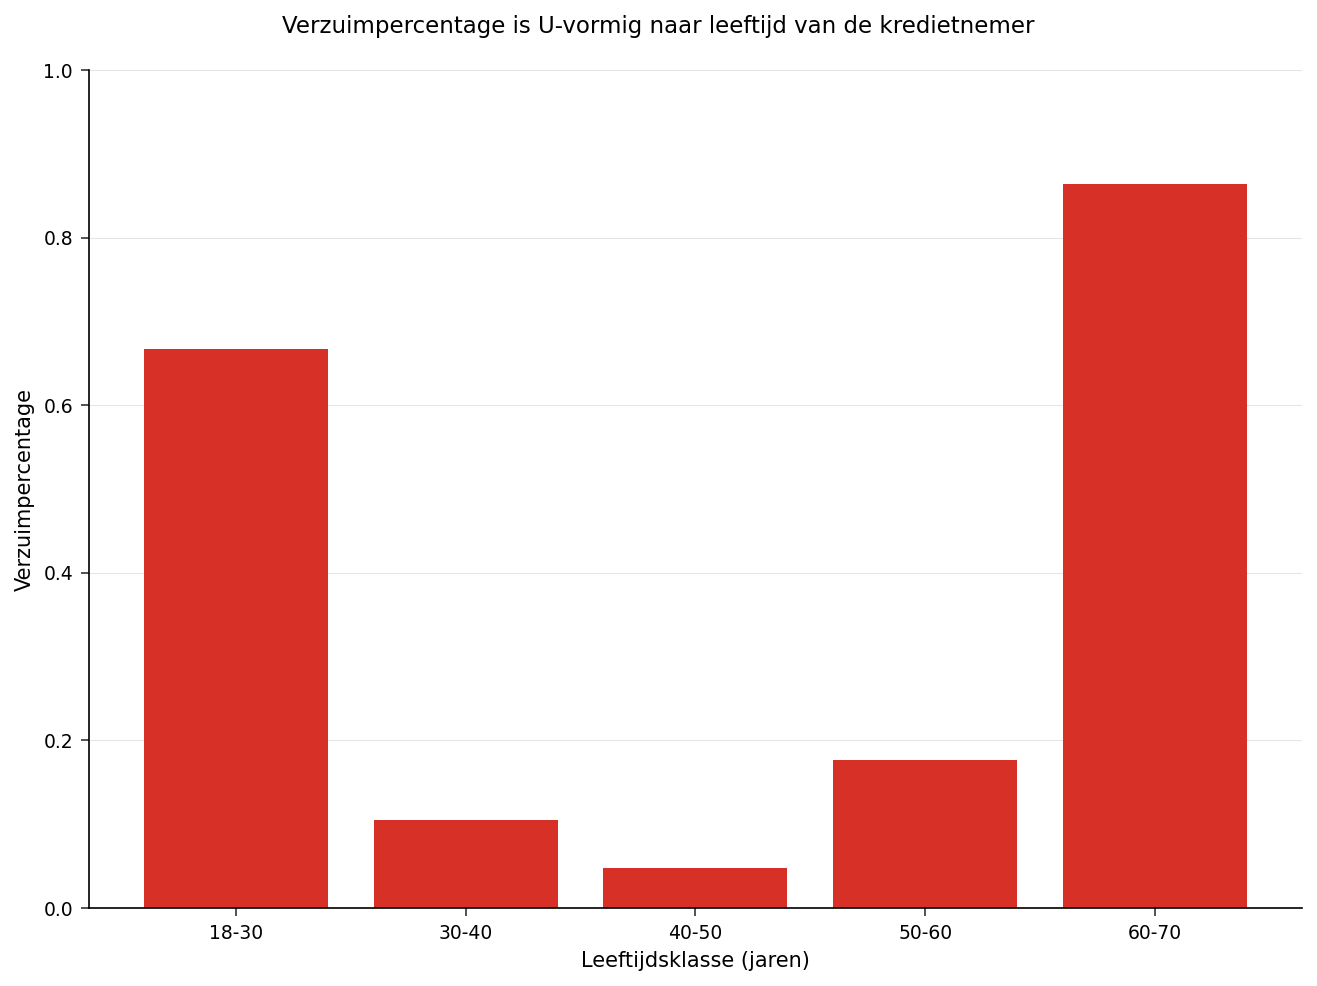

In [4]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT GEGEVENS=age_rate noautolegend;
   TITEL "Verzuimpercentage is U-vormig naar leeftijd van de kredietnemer";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS label="Verzuimpercentage" VALUES=(0 TOT 1 VOLGENS 0.2) grid;
   XAXIS label="Leeftijdsklasse (jaren)";
UITVOEREN;

TITEL;
ODS GRAPHICS OFF;

### Risico loopt op met hefboomwerking

De schuld-inkomenbanden trekken omhoog — de meest gehefboomde kredietnemers komen het vaakst in verzuim — consistent met de dominante dti-smooth in het model. De middelste banden zijn rumoerig bij deze steekproefgrootte, wat onderstreept waarom de gefitte spline een stabielere leidraad is dan welke handgetekende grens ook.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


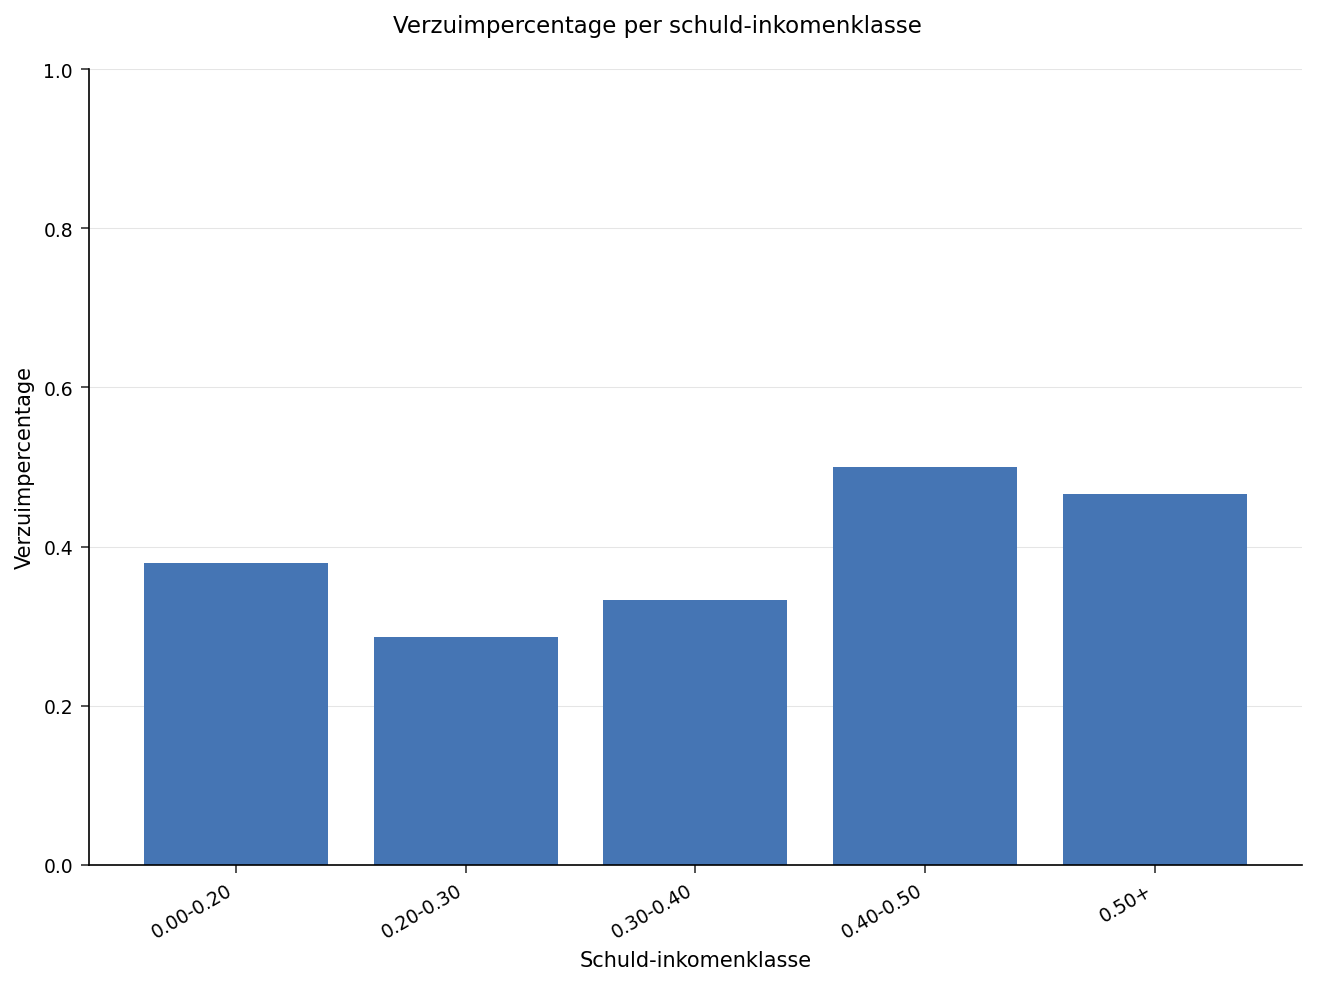

In [5]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT GEGEVENS=dti_rate noautolegend;
   TITEL "Verzuimpercentage per schuld-inkomenklasse";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS label="Verzuimpercentage" VALUES=(0 TOT 1 VOLGENS 0.2) grid;
   XAXIS label="Schuld-inkomenklasse";
UITVOEREN;

TITEL;
ODS GRAPHICS OFF;

## De resultaten interpreteren

`PROC GAM` vond de niet-lineaire structuur terug die we in de synthetische portefeuille hadden ingebouwd, zonder enige handmatige klasse-indeling of polynoomterm:

- **Sterke totale fit** - het additieve splinemodel drijft de deviantie van 133,75 omlaag naar 61,69 (een reductie van 72,06) voor een model-AIC van 81,69, op een boek met een basisverzuimpercentage van 39%.
- **Hefboomwerking domineert** - de schuld-inkomensmooth draagt de grootste coëfficiënt (4,34) van de drie termen, wat dti als de leidende drijver van de gefitte log-odds aanwijst.
- **Kromming in leeftijd** - het in klassen verdelen van de ruwe uitkomst bevestigt een leerboek-U: 66,7% verzuim in de band onder de 30, een dal van 4,8% bij 40-50, en 86,4% voor de band van 60 en ouder — de vorm die een kubische spline vanzelf vangt maar die één lineaire leeftijdsterm volledig zou missen.
- **Eerlijk over ruis** - bij 100 leningen wiebelen de schuld-inkomenpercentages per band, precies het argument voor een smooth-schatting boven een harde, met de hand gekozen grens.

**Waarom dit ertoe doet voor het bankwezen:** additieve splines geven een risicoteam een snelle, automatische manier om te detecteren waar een verband echt niet-lineair is, voordat het zich vastlegt op een productiescorekaart. De gefitte smooths zijn direct interpreteerbaar als risicocurves — een leeftijdspremie voor jong en oud, een hefboomhelling — en de deviantie en AIC kwantificeren hoeveel die flexibiliteit oplevert boven een vlak lineair model.